<a href="https://colab.research.google.com/github/Mandar-Ghatekar/IEX-Electricity-Market-Analysis/blob/main/IEX_Electicity_Market_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import os

file_path = 'DAM_Market Snapshot.xlsx'
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Critical Error: The file '{file_path}' was not found.")
df = pd.read_excel('DAM_Market Snapshot.xlsx')

print(f"Total rows (Time Blocks): {df.shape[0]}")
print(f"Total data columns: {df.shape[1]}")

display(df.head(20))

Total rows (Time Blocks): 105
Total data columns: 8


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,Market Snapshot,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Date: 15-06-2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Date,Hour,Time Block,Purchase Bid (MW),Sell Bid (MW),MCV (MW),Final Scheduled Volume (MW),MCP (Rs/MWh) *
4,15-06-2026,1,00:00 - 00:15,13866.10,8305.30,6036.00,6036.00,5499.53
5,15-06-2026,1,00:15 - 00:30,13674.90,8648.40,5972.50,5972.50,5450.63
6,15-06-2026,1,00:30 - 00:45,13469.40,8898.80,5883.09,5883.09,4872.41
7,15-06-2026,1,00:45 - 01:00,13737.70,9245.80,6573.20,6573.20,5000.10
8,15-06-2026,2,01:00 - 01:15,13765.40,9660.50,6806.50,6806.50,5000.02
9,15-06-2026,2,01:15 - 01:30,12961.50,9718.60,6751.50,6751.50,4999.19


In [ ]:
import pandas as pd
# Loading Day-Ahead Market (DAM) data and isolating a single 24-hour cycle (96 blocks)
df1 = pd.read_excel('DAM_Market Snapshot.xlsx',skiprows=4)
display(df1.head(10))
df1 = df1.iloc[:96]
total_rows = df1.shape[0]
total_columns = df1.shape[1]
print(f"Total rows are {total_rows}")
print(f"Total columns are {total_columns}")

print("\n=== Checking DATA TYPE  ===")
print(df1.dtypes)
df1['Purchase Bid (MW)'] = pd.to_numeric(df1['Purchase Bid (MW)'],errors = 'coerce')
df1['Sell Bid (MW)'] = pd.to_numeric(df1['Sell Bid (MW)'], errors='coerce')

print("\n=== RE-CHECKING DATA TYPES ===")
print(df1.dtypes)
missing_values = df1.isnull().sum()
print(missing_values)
print(df1.describe())


,Date,Hour,Time Block,Purchase Bid (MW),Sell Bid (MW),MCV (MW),Final Scheduled Volume (MW),MCP (Rs/MWh) *
0,15-06-2026,1,00:00 - 00:15,13866.10,8305.30,6036.00,6036.00,5499.53
1,15-06-2026,1,00:15 - 00:30,13674.90,8648.40,5972.50,5972.50,5450.63
2,15-06-2026,1,00:30 - 00:45,13469.40,8898.80,5883.09,5883.09,4872.41
3,15-06-2026,1,00:45 - 01:00,13737.70,9245.80,6573.20,6573.20,5000.10
4,15-06-2026,2,01:00 - 01:15,13765.40,9660.50,6806.50,6806.50,5000.02
5,15-06-2026,2,01:15 - 01:30,12961.50,9718.60,6751.50,6751.50,4999.19
6,15-06-2026,2,01:30 - 01:45,12502.40,9822.20,6399.00,6399.00,4576.33
7,15-06-2026,2,01:45 - 02:00,11909.40,10386.30,6263.00,6263.00,4449.65
8,15-06-2026,3,02:00 - 02:15,11252.30,11142.80,5915.80,5915.80,4295.07
9,15-06-2026,3,02:15 - 02:30,11202.30,11373.50,5946.60,5946.60,4002.74


Total rows are 96
Total columns are 8

=== Checking DATA TYPE  ===
Date                            object
Hour                            object
Time Block                      object
Purchase Bid (MW)               object
Sell Bid (MW)                   object
MCV (MW)                        object
Final Scheduled Volume (MW)     object
MCP (Rs/MWh) *                 float64
dtype: object

=== RE-CHECKING DATA TYPES ===
Date                            object
Hour                            object
Time Block                      object
Purchase Bid (MW)              float64
Sell Bid (MW)                  float64
MCV (MW)                        object
Final Scheduled Volume (MW)     object
MCP (Rs/MWh) *                 float64
dtype: object
Date                           0
Hour                           0
Time Block                     0
Purchase Bid (MW)              0
Sell Bid (MW)                  0
MCV (MW)                       0
Final Scheduled Volume (MW)    0
MCP (Rs/MWh) *    

In [ ]:
# Making the data suitable for the future model training
df1['start_time'] = df1['Time Block'].str.split(' - ').str[0]
df1['Timestamp_Str'] = df1['Date'] + ' ' + df1['start_time']
df1['Timestamp'] = pd.to_datetime(df1['Timestamp_Str'], format='%d-%m-%Y %H:%M')
df1.set_index('Timestamp', inplace=True)
df1.drop(columns=['start_time', 'Timestamp_Str'], inplace=True)
df1.drop(columns=['Date', 'Time Block', 'Hour'], inplace=True, errors='ignore')
df1.head()



,Purchase Bid (MW),Sell Bid (MW),MCV (MW),Final Scheduled Volume (MW),MCP (Rs/MWh) *
Timestamp,,,,,
2026-06-15 00:00:00,13866.1,8305.3,6036.00,6036.00,5499.53
2026-06-15 00:15:00,13674.9,8648.4,5972.50,5972.50,5450.63
2026-06-15 00:30:00,13469.4,8898.8,5883.09,5883.09,4872.41
2026-06-15 00:45:00,13737.7,9245.8,6573.20,6573.20,5000.10
2026-06-15 01:00:00,13765.4,9660.5,6806.50,6806.50,5000.02


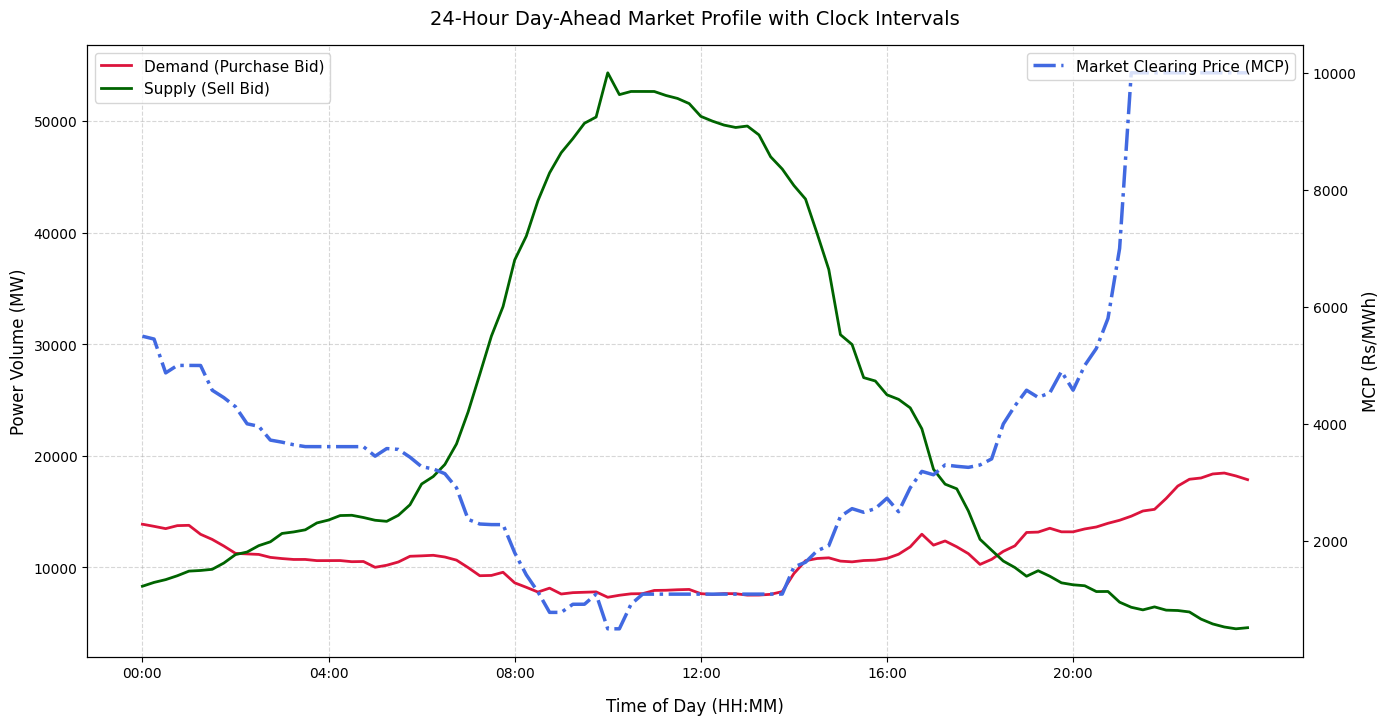

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df1['Timestamp'] = pd.to_datetime(df1['Timestamp'])
df1['Time_Stamp'] = df1['Timestamp'].dt.strftime('%H:%M')

fig, ax1 = plt.subplots(figsize=(14, 7))

x_positions = range(len(df1))
ax1.plot(x_positions, df1['Purchase Bid (MW)'], label='Demand (Purchase Bid)', color='crimson', lw=2)
ax1.plot(x_positions, df1['Sell Bid (MW)'], label='Supply (Sell Bid)', color='darkgreen', lw=2)

ax1.set_xlabel('Time of Day (HH:MM)', fontsize=12, labelpad=12)
ax1.set_ylabel('Power Volume (MW)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()
ax2.plot(x_positions, df1['MCP (Rs/MWh) *'], label='Market Clearing Price (MCP)', color='royalblue', lw=2.5, linestyle='-.')
ax2.set_ylabel('MCP (Rs/MWh)', fontsize=12)

tick_indices = list(range(0, len(df1), 16))
tick_labels = [df1['Time_Stamp'].iloc[i] for i in tick_indices]

ax1.set_xticks(tick_indices)
ax1.set_xticklabels(tick_labels, fontsize=10)

plt.tight_layout()

plt.title('24-Hour Day-Ahead Market Profile with Clock Intervals', fontsize=14, pad=15)
ax1.legend(loc='upper left', fontsize=11)
ax2.legend(loc='upper right', fontsize=11)

plt.show()

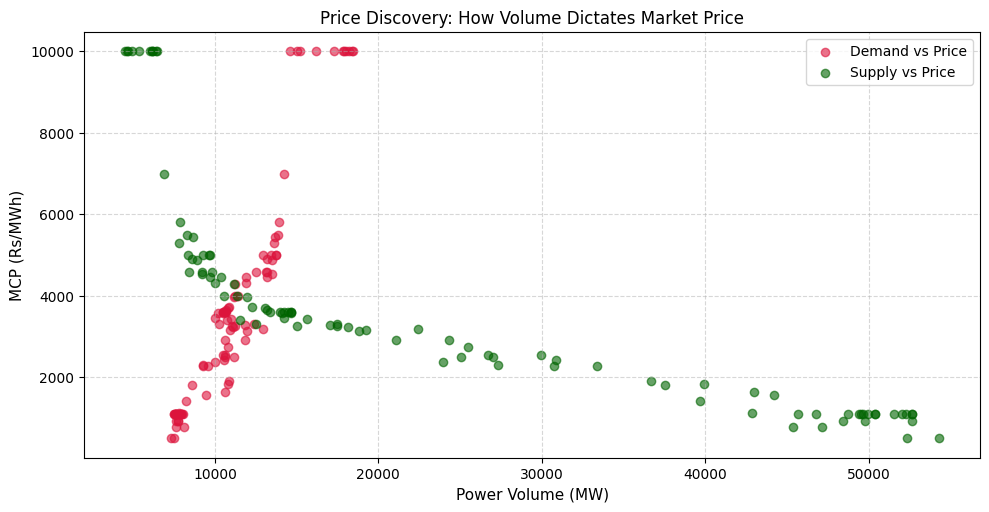

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

# Plot Demand vs Price as dots, and Supply vs Price as dots
ax.scatter(df1['Purchase Bid (MW)'], df1['MCP (Rs/MWh) *'], color='crimson', alpha=0.6, label='Demand vs Price')
ax.scatter(df1['Sell Bid (MW)'], df1['MCP (Rs/MWh) *'], color='darkgreen', alpha=0.6, label='Supply vs Price')

ax.set_xlabel('Power Volume (MW)', fontsize=11)
ax.set_ylabel('MCP (Rs/MWh)', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()

plt.tight_layout()
plt.title('Price Discovery: How Volume Dictates Market Price', fontsize=12)
plt.show()

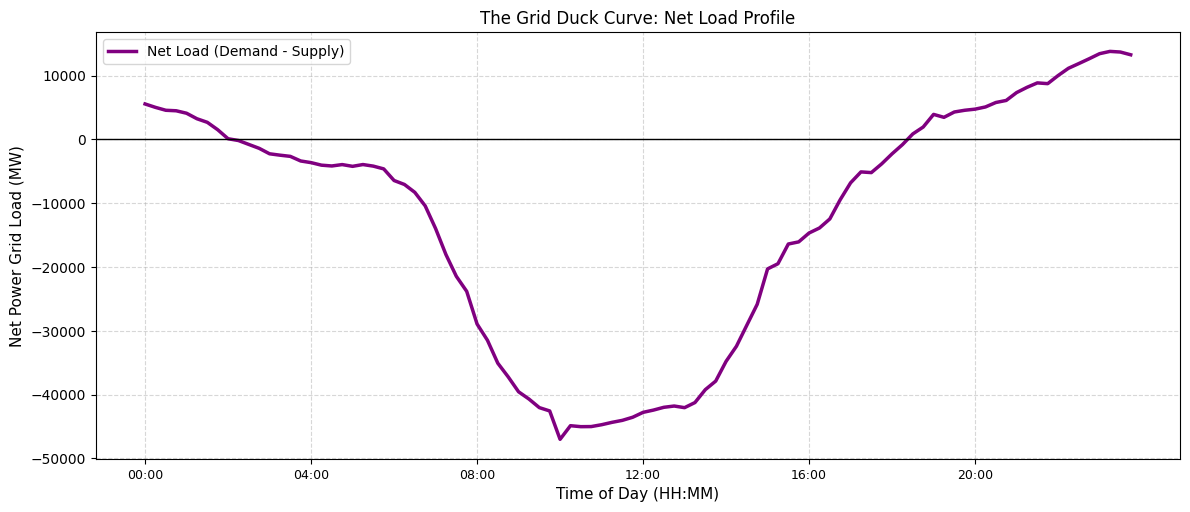

In [ ]:
import matplotlib.pyplot as plt

df1['Net_Load'] = df1['Purchase Bid (MW)'] - df1['Sell Bid (MW)']

fig, ax = plt.subplots(figsize=(12, 5))

x_positions = range(len(df1))
ax.plot(x_positions, df1['Net_Load'], color='purple', lw=2.5, label='Net Load (Demand - Supply)')
ax.axhline(0, color='black', lw=1, linestyle='-')

ax.set_xlabel('Time of Day (HH:MM)', fontsize=11)
ax.set_ylabel('Net Power Grid Load (MW)', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)

tick_indices = list(range(0, len(df1), 16))
tick_labels = [df1['Time_Stamp'].iloc[i] for i in tick_indices]
ax.set_xticks(tick_indices)
ax.set_xticklabels(tick_labels, fontsize=9)

plt.tight_layout()
plt.title('The Grid Duck Curve: Net Load Profile', fontsize=12)
plt.legend()
plt.show()